In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scanpy as sc
sns.set(style="whitegrid", context="talk")
plt.rcParams["pdf.fonttype"] = 42


In [3]:
# Base path
data_path = "/N/u/echimal/Quartz/Desktop/CLR_MRI/Human_GeoMx_Sep2025"

# Load abundance tables
df_wide = pd.read_csv( "cell2location_abundance_wide_with_meta.csv"
)

df_long = pd.read_csv( "cell2location_abundance_long_rel.csv"
)

print(df_wide.shape)
print(df_long.head())


(190, 103)
   ROI            Scan_ID disease_status pathology    region  \
0    0  BRC 2534 BRC 2732         AD-CAA   Amyloid  Arteries   
1    1  BRC 2534 BRC 2732         AD-CAA   Amyloid  Arteries   
2    2  BRC 2534 BRC 2732         AD-CAA   Amyloid  Arteries   
3    3  BRC 2534 BRC 2732         AD-CAA   Amyloid  Arteries   
4    4  BRC 2534 BRC 2732         AD-CAA   Amyloid  Arteries   

            celltype  rel_abundance  
0  Oligodendrocytes4       0.027669  
1  Oligodendrocytes4       0.021056  
2  Oligodendrocytes4       0.021896  
3  Oligodendrocytes4       0.020941  
4  Oligodendrocytes4       0.033452  


In [4]:
df_long.groupby("disease_status")["ROI"].nunique()

disease_status
AD-CAA     145
Control     45
Name: ROI, dtype: int64

In [5]:
def plot_celltype_by_group(
    df_long,
    celltype,
    group="disease_status",
    hue=None,
    title=None
):
    tmp = df_long[df_long["celltype"] == celltype].copy()

    plt.figure(figsize=(6,4))
    sns.boxplot(data=tmp, x=group, y="rel_abundance", hue=hue)
    sns.stripplot(
        data=tmp,
        x=group, y="rel_abundance",
        hue=hue, dodge=True, alpha=0.4, color="black"
    )
    plt.title(title or f"{celltype} by {group}")
    plt.tight_layout()
    plt.show()


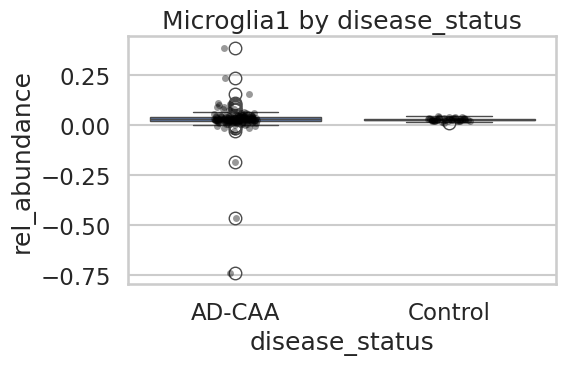

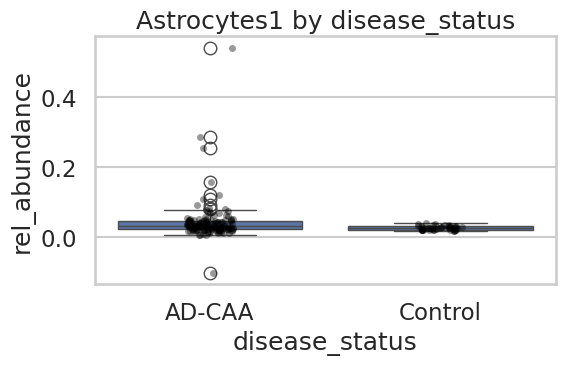

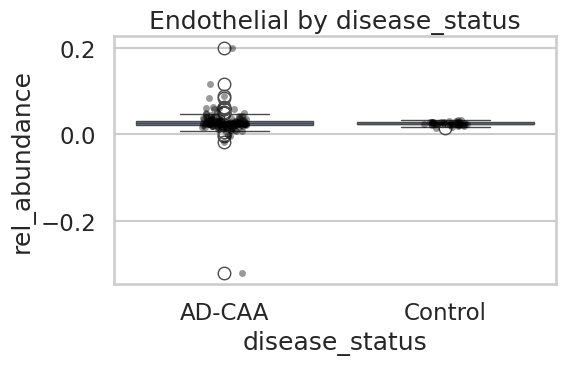

In [6]:
for ct in ["Microglia1", "Astrocytes1", "Endothelial"]:
    plot_celltype_by_group(
        df_long,
        celltype=ct,
        group="disease_status"
    )


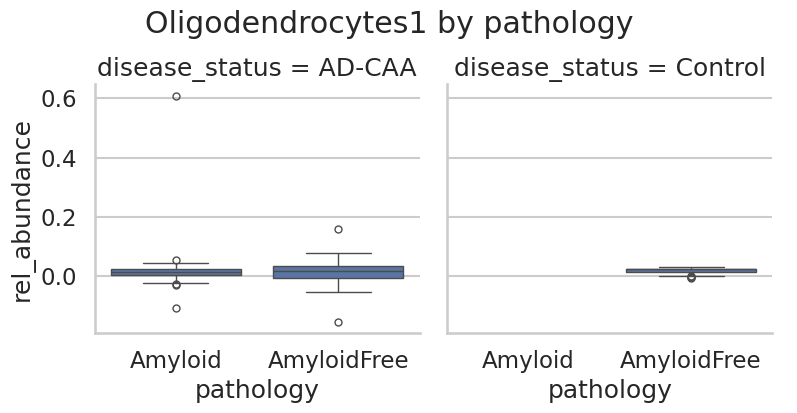

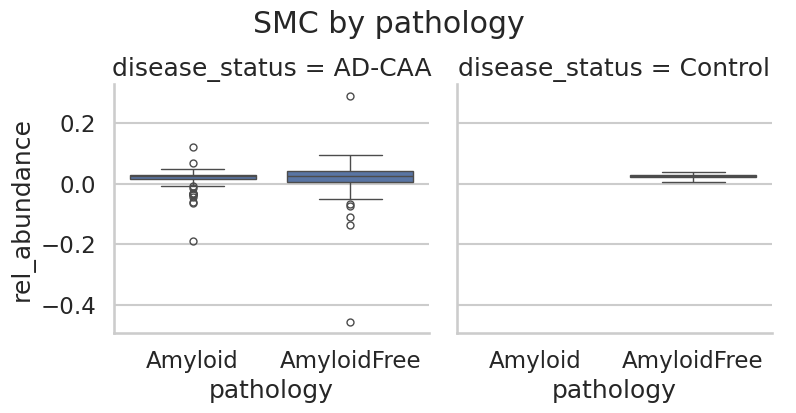

In [7]:
for ct in ["Oligodendrocytes1", "SMC"]:
    tmp = df_long[df_long["celltype"] == ct]

    g = sns.catplot(
        data=tmp,
        x="pathology",
        y="rel_abundance",
        col="disease_status",
        kind="box",
        height=4,
        aspect=1
    )
    g.fig.suptitle(f"{ct} by pathology", y=1.05)
    plt.show()


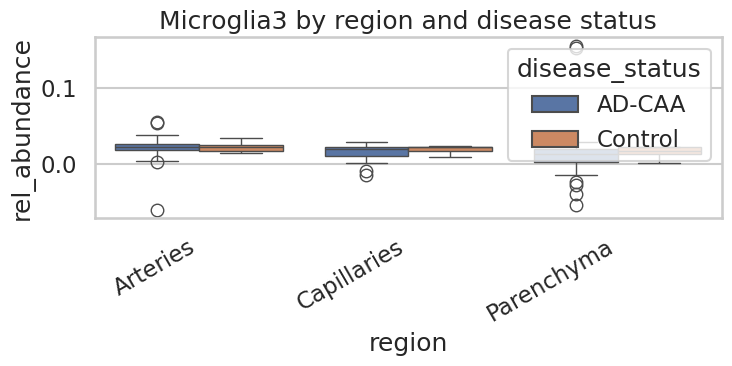

In [8]:
ct = "Microglia3"

tmp = df_long[df_long["celltype"] == ct]

plt.figure(figsize=(8,4))
sns.boxplot(
    data=tmp,
    x="region",
    y="rel_abundance",
    hue="disease_status"
)
plt.xticks(rotation=30, ha="right")
plt.title(f"{ct} by region and disease status")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1243396/1167819600.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


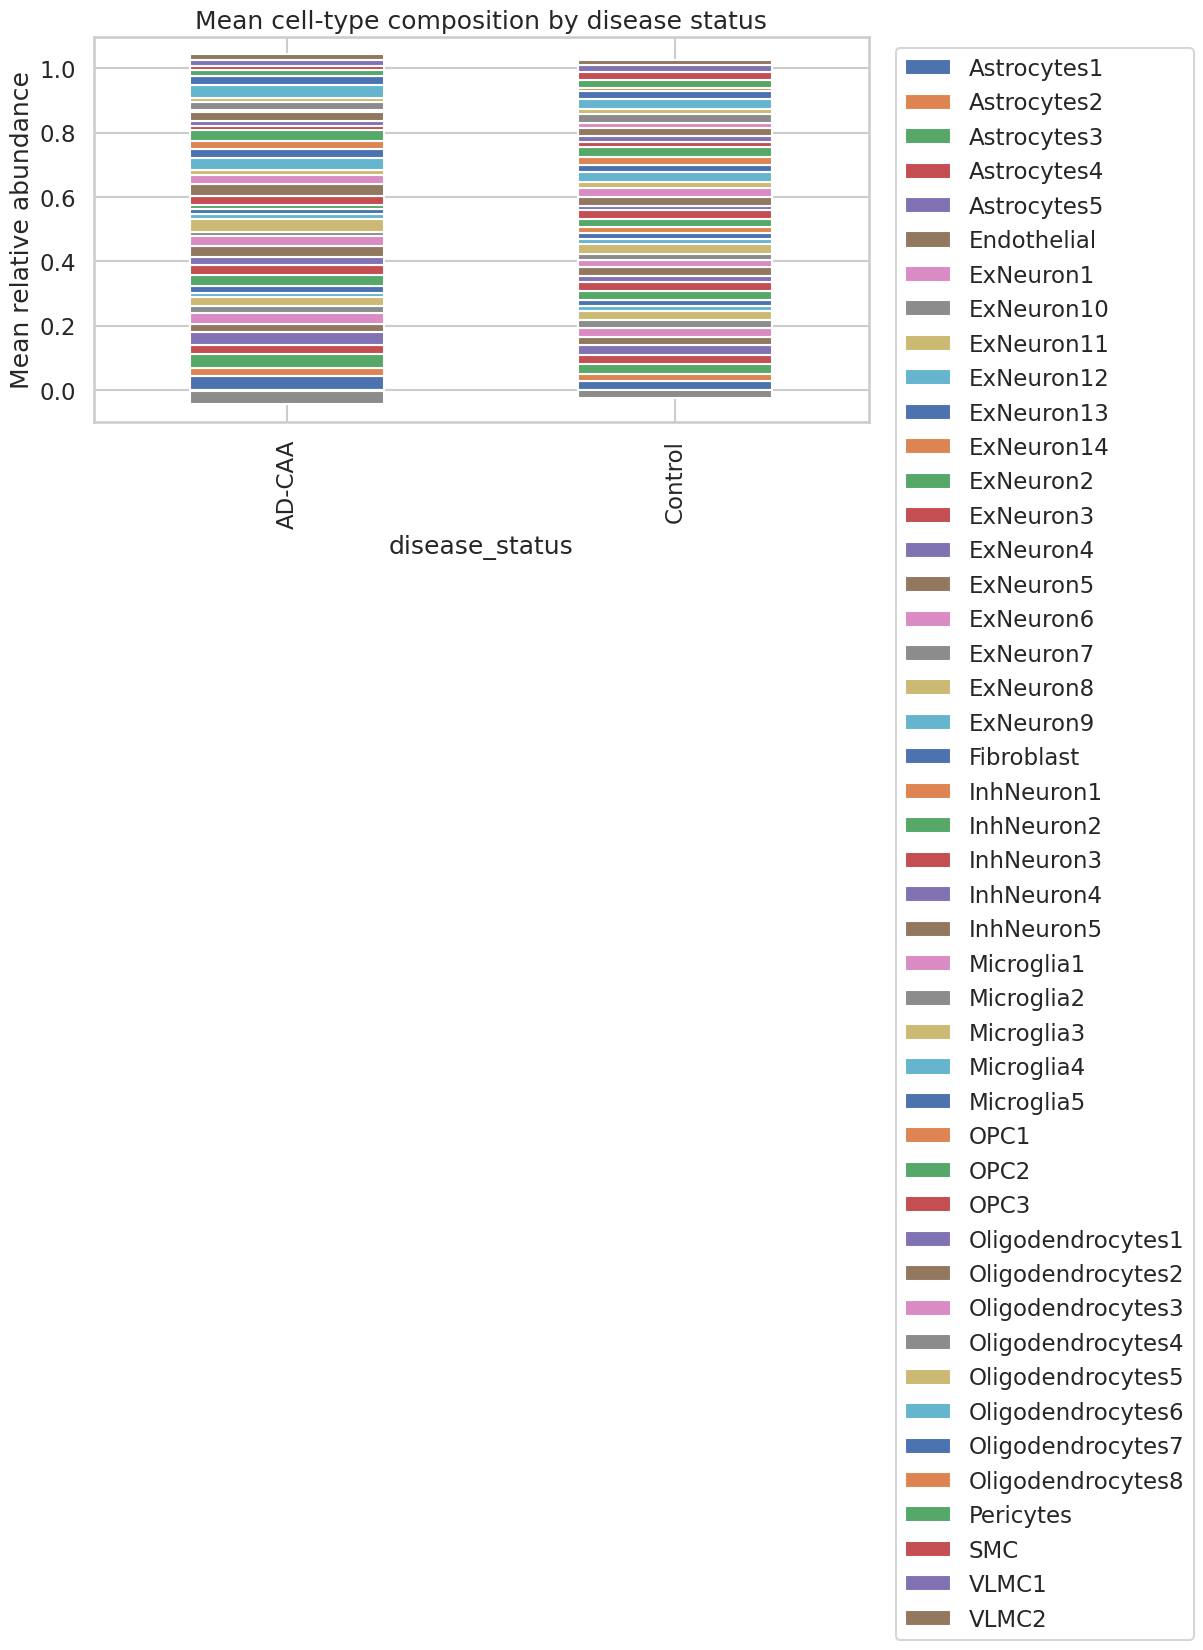

In [9]:
mean_mix = (
    df_long
    .groupby(["disease_status", "celltype"])["rel_abundance"]
    .mean()
    .reset_index()
)

mix_piv = mean_mix.pivot(
    index="disease_status",
    columns="celltype",
    values="rel_abundance"
).fillna(0)

mix_piv.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)
plt.ylabel("Mean relative abundance")
plt.title("Mean cell-type composition by disease status")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [12]:
#####Statistics section
#Simple non-parametric test 
from scipy.stats import mannwhitneyu

stats = []

for ct in df_long["celltype"].unique():
    tmp = df_long[df_long["celltype"] == ct]

    g1 = tmp[tmp["disease_status"] == "AD-CAA"]["rel_abundance"]
    g2 = tmp[tmp["disease_status"] == "Control"]["rel_abundance"]

    if len(g1) > 5 and len(g2) > 5:
        u, p = mannwhitneyu(g1, g2, alternative="two-sided")
        stats.append([ct, p, g1.mean(), g2.mean()])

stats_df = pd.DataFrame(
    stats,
    columns=["celltype", "p_value", "mean_ADCAA", "mean_CTRL"]
).sort_values("p_value")

stats_df.to_csv("celltype_disease_stats_Mannwhitey.csv", index=False)

stats_df.head(10)

,celltype,p_value,mean_ADCAA,mean_CTRL
30,InhNeuron4,1.383553e-08,0.000968,0.009760
20,Microglia2,1.495096e-04,-0.040160,-0.026946
18,OPC2,4.927180e-04,0.034121,0.029896
15,Astrocytes3,9.720168e-04,0.043147,0.030397
9,ExNeuron3,1.097077e-03,0.032798,0.027804
10,ExNeuron2,2.262902e-03,0.035308,0.028320
23,InhNeuron5,3.012290e-03,0.036609,0.030132
25,ExNeuron5,3.466333e-03,0.034188,0.028112
8,Astrocytes1,3.865850e-03,0.042366,0.027332
21,ExNeuron8,9.743258e-03,0.039586,0.029836


In [ ]:
#Because the ROIs desgin is nested within Scan_ID (Slide/batch)
#the most correct way to handle this is through a Linear mixed model (LMM)
#We will go to R for better statistical handling  

